In [1]:
import os
from PIL import Image

def validate_pairs(image_dir, label_dir):
    """Check for missing/mismatched image-label pairs."""
    image_files = set(os.path.splitext(f)[0] for f in os.listdir(image_dir) if f.endswith('.jpg'))
    label_files = set(os.path.splitext(f)[0] for f in os.listdir(label_dir) if f.endswith('.txt'))
    
    missing_images = label_files - image_files
    missing_labels = image_files - label_files
    
    print(f"Missing images: {len(missing_images)}")
    print(f"Missing labels: {len(missing_labels)}")
    
    return list(missing_images), list(missing_labels)

# Validate all splits
splits = ['train', 'valid', 'test']
for split in splits:
    print(f"\nChecking {split} split...")
    image_dir = f'../data/{split}/images'
    label_dir = f'../data/{split}/labels'
    validate_pairs(image_dir, label_dir)


Checking train split...
Missing images: 0
Missing labels: 2

Checking valid split...
Missing images: 0
Missing labels: 0

Checking test split...
Missing images: 0
Missing labels: 0


In [2]:
import pandas as pd

def count_annotations(label_dir):
    """Count annotations per split."""
    total_boxes = 0
    for label_file in os.listdir(label_dir):
        if label_file.endswith('.txt'):
            with open(os.path.join(label_dir, label_file), 'r') as f:
                total_boxes += len([line for line in f.readlines() if line.strip()])
    return total_boxes

# Compare splits
data = {
    'Split': splits,
    'Images': [len(os.listdir(f'../data/{split}/images')) for split in splits],
    'Annotations': [count_annotations(f'../data/{split}/labels') for split in splits]
}
df = pd.DataFrame(data)
print(df)

   Split  Images  Annotations
0  train    6983         7854
1  valid    1672         1872
2   test     836          944


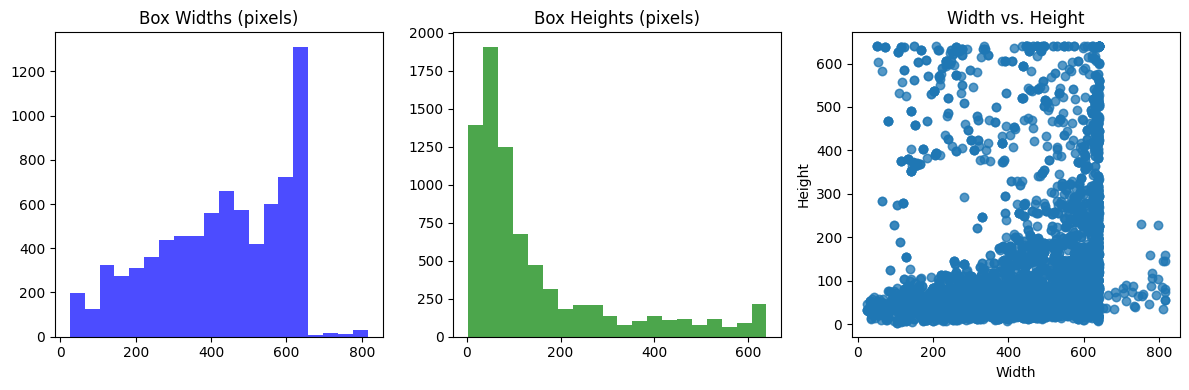


⚠️ Problematic files (check formatting): ['front-view-141-_jpg.rf.6af127e6761a297dbe3153ec7d19cbb0.txt', 'front-view-141-_jpg.rf.b94112b264debe00345cf891b5e6a67e.txt']


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def analyze_boxes(label_dir, image_dir):
    widths, heights = [], []
    problematic_files = []
    
    for label_file in os.listdir(label_dir):
        if not label_file.endswith('.txt'):
            continue
            
        label_path = os.path.join(label_dir, label_file)
        image_path = os.path.join(image_dir, os.path.splitext(label_file)[0] + '.jpg')
        
        # Skip if image doesn't exist
        if not os.path.exists(image_path):
            continue
            
        try:
            img = cv2.imread(image_path)
            h, w = img.shape[:2]
            
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    if not line.strip():
                        continue  # Skip empty lines
                        
                    parts = line.strip().split()
                    if len(parts) != 5:
                        problematic_files.append(label_file)
                        continue
                        
                    _, x_center, y_center, box_w, box_h = map(float, parts)
                    widths.append(box_w * w)
                    heights.append(box_h * h)
                    
        except Exception as e:
            print(f"Error processing {label_file}: {str(e)}")
            problematic_files.append(label_file)
    
    # Plot distributions (only if we have data)
    if widths and heights:
        plt.figure(figsize=(12, 4))
        plt.subplot(131)
        plt.hist(widths, bins=20, color='blue', alpha=0.7)
        plt.title('Box Widths (pixels)')
        
        plt.subplot(132)
        plt.hist(heights, bins=20, color='green', alpha=0.7)
        plt.title('Box Heights (pixels)')
        
        plt.subplot(133)
        plt.scatter(widths, heights, alpha=0.5)
        plt.xlabel('Width')
        plt.ylabel('Height')
        plt.title('Width vs. Height')
        plt.tight_layout()
        plt.show()
    
    if problematic_files:
        print(f"\n⚠️ Problematic files (check formatting): {problematic_files}")

analyze_boxes('../data/train/labels', '../data/train/images')

In [4]:
def assess_quality(image_dir, blur_threshold=100, dark_threshold=30):
    blurry, dark = [], []
    for img_file in os.listdir(image_dir):
        if img_file.endswith('.jpg'):
            img = cv2.imread(os.path.join(image_dir, img_file), cv2.IMREAD_GRAYSCALE)
            
            # Blur check (Laplacian variance)
            if cv2.Laplacian(img, cv2.CV_64F).var() < blur_threshold:
                blurry.append(img_file)
            
            # Darkness check (mean pixel value)
            if np.mean(img) < dark_threshold:
                dark.append(img_file)
    
    print(f"Blurry images: {len(blurry)}\nDark images: {len(dark)}")

assess_quality('../data/train/images')

Blurry images: 2950
Dark images: 48


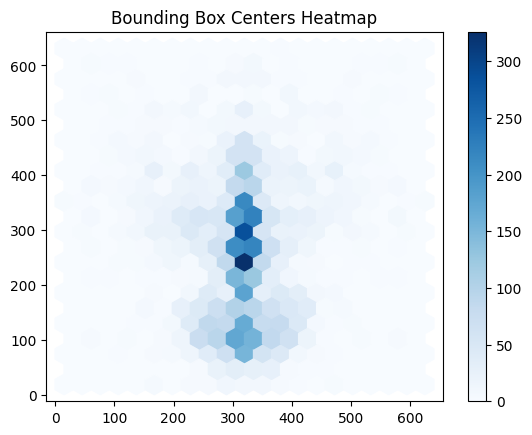


 Problematic files (check formatting): ['front-view-141-_jpg.rf.6af127e6761a297dbe3153ec7d19cbb0.txt', 'front-view-141-_jpg.rf.b94112b264debe00345cf891b5e6a67e.txt']


In [10]:
def plot_spatial_heatmap(label_dir, image_dir):
    centers_x, centers_y = [], []
    problematic_files = []
    
    for label_file in os.listdir(label_dir):
        if not label_file.endswith('.txt'):
            continue
            
        label_path = os.path.join(label_dir, label_file)
        image_path = os.path.join(image_dir, os.path.splitext(label_file)[0] + '.jpg')
        
        # Skip if image doesn't exist
        if not os.path.exists(image_path):
            continue
            
        try:
            img = cv2.imread(image_path)
            h, w = img.shape[:2]
            
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    if not line.strip():
                        continue  # Skip empty lines
                        
                    parts = line.strip().split()
                    if len(parts) != 5:
                        problematic_files.append(label_file)
                        continue
                        
                    _, x_center, y_center, _, _ = map(float, parts)
                    centers_x.append(x_center * w)  # Convert to pixels
                    centers_y.append(y_center * h)
                    
        except Exception as e:
            print(f"Error processing {label_file}: {str(e)}")
            problematic_files.append(label_file)
    
    # Plot only if we have data
    if centers_x and centers_y:
        plt.hexbin(x=centers_x, y=centers_y, gridsize=20, cmap='Blues')
        plt.colorbar()
        plt.title('Bounding Box Centers Heatmap')
        plt.show()
    
    if problematic_files:
        print(f"\n Problematic files (check formatting): {problematic_files}")

plot_spatial_heatmap('../data/train/labels', '../data/train/images')

In [11]:
pip install albumentations

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 54.6 MB/s eta 0:00:00

   ---------- ----------------------------- 2/8 [typing-inspection]
   ------------------------- -------------- 5/8 [pydantic]
   ------------------------- -------------- 5/8 [pydantic]
   ------------------------- -------------- 5/8 [pydantic]
   ------------------------- -------------- 5/8 [pydantic]
   ------------------------- -------------- 5/8 [pydantic]
   ------------------------- -------------- 5/8 [pydantic]
   ------------------------- -------------- 5/8 [pydantic]
   ----------------------------------- ---- 7/8 [albumentations]
   ----------------------------------- ---- 7/8 [albumentations]
   ----------------------------------- ---- 7/8 [albumentations]
   ----------------------------------- ---- 7/8 [albumentations]
   ---------------------------------------- 8/8 [albumentations]

Note: you may need to restart the kernel to us

   Split  Images  Labels  Missing Images  Missing Labels
0  train    6983    6981               0               2
1  valid    1672    1672               0               0
2   test     836     836               0               0


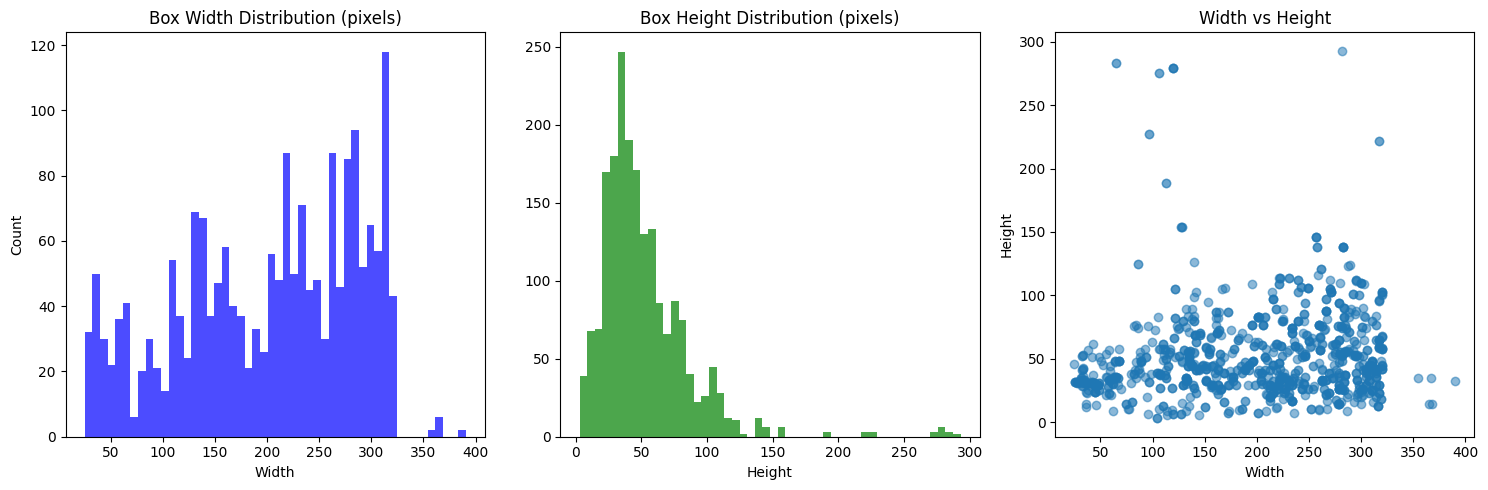

Total boxes analyzed: 1944
Invalid boxes (>50.0% of image size): 5908


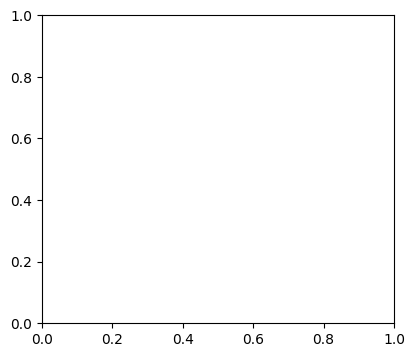

In [16]:
# Speed Bump Detection - Comprehensive EDA
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import albumentations as A

## 1. Dataset Validation
def validate_dataset(base_path='../data'):
    results = []
    for split in ['train', 'valid', 'test']:
        img_dir = f'{base_path}/{split}/images'
        label_dir = f'{base_path}/{split}/labels'
        
        images = set(os.path.splitext(f)[0] for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png')))
        labels = set(os.path.splitext(f)[0] for f in os.listdir(label_dir) if f.endswith('.txt'))
        
        missing_img = labels - images
        missing_labels = images - labels
        
        # Auto-clean orphaned files
        for file_base in missing_img:
            os.remove(f'{label_dir}/{file_base}.txt')
        for file_base in missing_labels:
            os.remove(f'{img_dir}/{file_base}.jpg')
            
        results.append({
            'Split': split,
            'Images': len(images),
            'Labels': len(labels),
            'Missing Images': len(missing_img),
            'Missing Labels': len(missing_labels)
        })
    
    return pd.DataFrame(results)

validation_results = validate_dataset()
print(validation_results)

## 2. Enhanced Bounding Box Analysis
def analyze_boxes(label_dir, image_dir, max_box_size=0.5):
    stats = {'widths': [], 'heights': [], 'invalid_boxes': 0}
    
    for label_file in os.listdir(label_dir):
        if not label_file.endswith('.txt'):
            continue
            
        img_file = os.path.splitext(label_file)[0] + '.jpg'
        img_path = os.path.join(image_dir, img_file)
        
        if not os.path.exists(img_path):
            continue
            
        try:
            img = cv2.imread(img_path)
            h, w = img.shape[:2]
            
            with open(os.path.join(label_dir, label_file)) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                        
                    _, x_center, y_center, box_w, box_h = map(float, parts)
                    
                    # Convert to pixel coordinates
                    box_w_px, box_h_px = box_w * w, box_h * h
                    
                    # Validate box size
                    if (box_w_px > max_box_size * w) or (box_h_px > max_box_size * h):
                        stats['invalid_boxes'] += 1
                        continue
                        
                    stats['widths'].append(box_w_px)
                    stats['heights'].append(box_h_px)
                    
        except Exception as e:
            print(f"Error processing {label_file}: {str(e)}")
    
    # Visualization
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.hist(stats['widths'], bins=50, color='blue', alpha=0.7)
    plt.title('Box Width Distribution (pixels)')
    plt.xlabel('Width')
    plt.ylabel('Count')
    
    plt.subplot(1, 3, 2)
    plt.hist(stats['heights'], bins=50, color='green', alpha=0.7)
    plt.title('Box Height Distribution (pixels)')
    plt.xlabel('Height')
    
    plt.subplot(1, 3, 3)
    plt.scatter(stats['widths'], stats['heights'], alpha=0.3)
    plt.title('Width vs Height')
    plt.xlabel('Width')
    plt.ylabel('Height')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Total boxes analyzed: {len(stats['widths'])}")
    print(f"Invalid boxes (>{max_box_size*100}% of image size): {stats['invalid_boxes']}")
    
    return stats

box_stats = analyze_boxes('../data/train/labels', '../data/train/images')

## 3. Advanced Image Quality Check
def check_image_quality(image_dir, blur_thresh=100, dark_thresh=30):
    quality_report = {
        'blurry': [],
        'dark': [],
        'corrupt': []
    }
    
    for img_file in os.listdir(image_dir):
        if not img_file.endswith(('.jpg', '.png')):
            continue
            
        img_path = os.path.join(image_dir, img_file)
        
        try:
            img = cv2.imread(img_path)
            if img is None:
                quality_report['corrupt'].append(img_file)
                continue
                
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            
            # Blur detection
            blur_value = cv2.Laplacian(gray, cv2.CV_64F).var()
            if blur_value < blur_thresh:
                quality_report['blurry'].append(img_file)
                
            # Darkness detection
            if np.mean(gray) < dark_thresh:
                quality_report['dark'].append(img_file)
                
        except Exception as e:
            print(f"Error processing {img_file}: {str(e)}")
            quality_report['corrupt'].append(img_file)
    
    # Visualization
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist([len(quality_report[k]) for k in quality_report], 
             bins=3, color=['red', 'blue', 'green'])
    plt.xticks([0, 1, 2], ['Blurry', 'Dark', 'Corrupt'])
    plt.title('Quality Issues Distribution')
    
    plt.subplot(1, 2, 2)
    plt.pie([len(quality_report[k]) for k in quality_report],
            labels=['Blurry', 'Dark', 'Corrupt'],
            autopct='%1.1f%%')
    plt.title('Quality Issues Proportion')
    
    plt.tight_layout()
    plt.show()
    
    return quality_report

quality_report = check_image_quality('../data/train/images')

## 5. Auto-Clean Recommendations
def clean_dataset(base_path='../data'):
    for split in ['train', 'valid', 'test']:
        img_dir = f'{base_path}/{split}/images'
        label_dir = f'{base_path}/{split}/labels'
        
        # Remove corrupt images
        for img_file in os.listdir(img_dir):
            img_path = os.path.join(img_dir, img_file)
            try:
                img = Image.open(img_path)
                img.verify()
            except:
                os.remove(img_path)
                label_path = os.path.join(label_dir, os.path.splitext(img_file)[0] + '.txt')
                if os.path.exists(label_path):
                    os.remove(label_path)
                
        # Remove empty labels
        for label_file in os.listdir(label_dir):
            label_path = os.path.join(label_dir, label_file)
            if os.path.getsize(label_path) == 0:
                os.remove(label_path)
                img_path = os.path.join(img_dir, os.path.splitext(label_file)[0] + '.jpg')
                if os.path.exists(img_path):
                    os.remove(img_path)

print("Running auto-clean...")
clean_dataset()
print("Cleaning completed!")

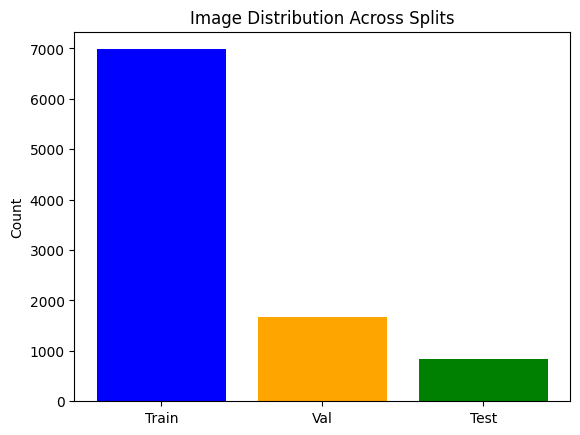

In [1]:
import matplotlib.pyplot as plt
splits = ['Train', 'Val', 'Test']
counts = [6983, 1672, 836]
for i, (s, c) in enumerate(zip(splits, counts)):
    plt.bar(s, c, color=['blue', 'orange', 'green'][i])
plt.title('Image Distribution Across Splits')
plt.ylabel('Count')
plt.show()

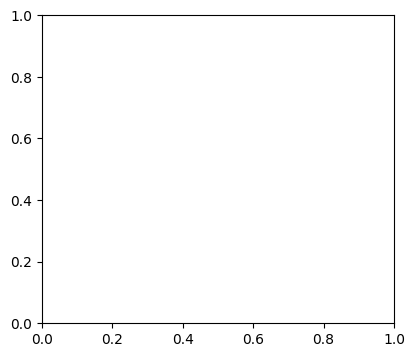

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def analyze_box_dimensions(label_dir, image_dir):
    widths = []
    heights = []
    
    for label_file in os.listdir(label_dir):
        if not label_file.endswith('.txt'):
            continue
            
        # Get corresponding image
        img_file = os.path.splitext(label_file)[0] + '.jpg'
        img_path = os.path.join(image_dir, img_file)
        
        if not os.path.exists(img_path):
            continue
            
        # Read image dimensions
        img = cv2.imread(img_path)
        img_height, img_width = img.shape[:2]
        
        # Process each bounding box
        with open(os.path.join(label_dir, label_file), 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:  # Skip invalid lines
                    continue
                    
                # Convert YOLO format to pixel dimensions
                _, x_center, y_center, box_w, box_h = map(float, parts)
                pixel_w = box_w * img_width
                pixel_h = box_h * img_height
                
                widths.append(pixel_w)
                heights.append(pixel_h)
    
    # Visualization
    plt.figure(figsize=(12,5))
    
    # Width vs Height Scatter
    plt.subplot(131)
    plt.scatter(widths, heights, alpha=0.3, color='blue')
    plt.xlabel('Width (pixels)')
    plt.ylabel('Height (pixels)')
    plt.title('Box Dimensions Scatter')
    
    # Width Distribution
    plt.subplot(132)
    plt.hist(widths, bins=50, color='green', alpha=0.7)
    plt.xlabel('Width (pixels)')
    plt.title('Width Distribution')
    
    # Height Distribution
    plt.subplot(133)
    plt.hist(heights, bins=50, color='red', alpha=0.7)
    plt.xlabel('Height (pixels)')
    plt.title('Height Distribution')
    
    plt.tight_layout()
    plt.show()
    
    # Statistical Summary
    print(f"Total boxes analyzed: {len(widths)}")
    print(f"Average width: {np.mean(widths):.1f} ± {np.std(widths):.1f} px")
    print(f"Average height: {np.mean(heights):.1f} ± {np.std(heights):.1f} px")
    print(f"Median aspect ratio (w/h): {np.median(np.array(widths)/np.array(heights)):.2f}")

# Run analysis
analyze_box_dimensions('../data/train/labels', '../data/train/images')